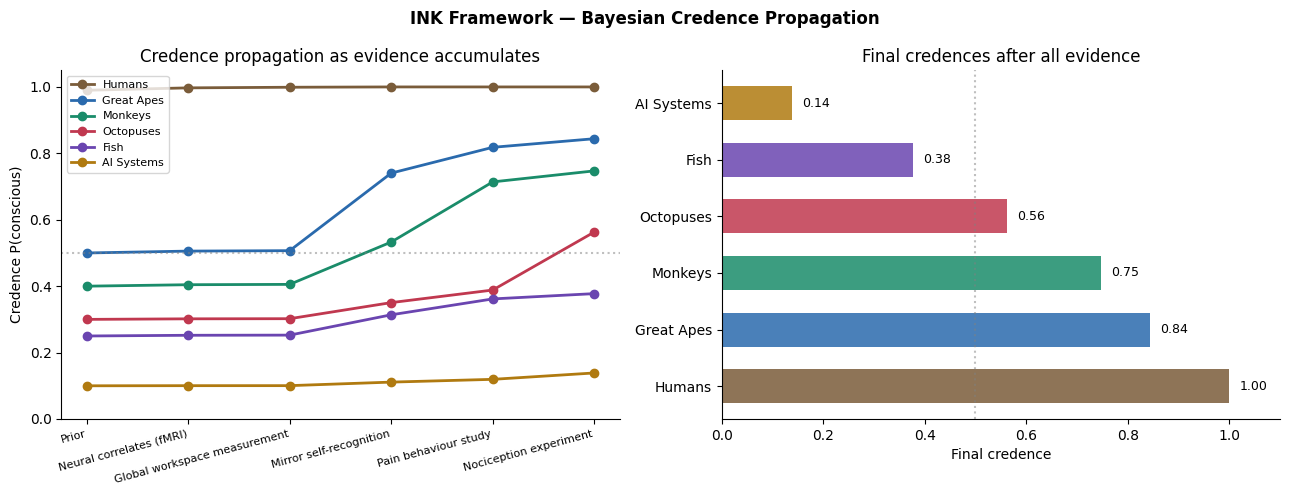


=== Final Credences ===
  Humans          1.000  ██████████████████████████████
  Great Apes      0.844  █████████████████████████
  Monkeys         0.747  ██████████████████████
  Octopuses       0.563  ████████████████
  Fish            0.378  ███████████
  AI Systems      0.139  ████


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Populations and similarity graph
populations = ['Humans', 'Great Apes', 'Monkeys', 'Octopuses', 'Fish', 'AI Systems']

edges = [
    ('Humans',     'Great Apes',  0.92),
    ('Great Apes', 'Monkeys',     0.78),
    ('Monkeys',    'Octopuses',   0.38),
    ('Monkeys',    'Fish',        0.48),
    ('Octopuses',  'AI Systems',  0.22),
    ('Fish',       'AI Systems',  0.18),
]

G = nx.Graph()
G.add_nodes_from(populations)
for src, tgt, sim in edges:
    G.add_edge(src, tgt, similarity=sim)

# Prior credences
credences = {
    'Humans':     0.99,
    'Great Apes': 0.50,
    'Monkeys':    0.40,
    'Octopuses':  0.30,
    'Fish':       0.25,
    'AI Systems': 0.10,
}

# Bayesian update at source node
def bayesian_update(prior, evidence_strength,
                    likelihood_hit=0.88, likelihood_miss=0.18):
    lh_c  = likelihood_hit  * evidence_strength + 0.5 * (1 - evidence_strength)
    lh_nc = likelihood_miss * evidence_strength + 0.5 * (1 - evidence_strength)
    numerator   = lh_c * prior
    denominator = lh_c * prior + lh_nc * (1 - prior)
    return numerator / denominator

# Propagate outward through similarity graph
def propagate(G, credences, source_node, evidence_strength):
    updated = credences.copy()
    updated[source_node] = bayesian_update(credences[source_node], evidence_strength)

    for node in nx.bfs_tree(G, source_node).nodes():
        if node == source_node:
            continue
        path = nx.shortest_path(G, source_node, node)
        transfer = 1.0
        for i in range(len(path) - 1):
            transfer *= G[path[i]][path[i+1]]['similarity']
        delta = updated[source_node] - credences[source_node]
        updated[node] = float(np.clip(
            credences[node] + transfer * evidence_strength * delta, 0, 1
        ))
    return updated

# Evidence sequence
evidence_sequence = [
    ('Humans',     0.85, 'Neural correlates (fMRI)'),
    ('Humans',     0.75, 'Global workspace measurement'),
    ('Great Apes', 0.70, 'Mirror self-recognition'),
    ('Monkeys',    0.55, 'Pain behaviour study'),
    ('Octopuses',  0.50, 'Nociception experiment'),
]

history = [credences.copy()]
labels  = ['Prior']
current = credences.copy()

for node, strength, label in evidence_sequence:
    current = propagate(G, current, node, strength)
    history.append(current.copy())
    labels.append(label)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {
    'Humans':     '#7a5c3a',
    'Great Apes': '#2a6aad',
    'Monkeys':    '#1a8c6a',
    'Octopuses':  '#c0384f',
    'Fish':       '#6a45b0',
    'AI Systems': '#b07a10',
}

# Panel A: credence trajectories
x = range(len(labels))
for pop in populations:
    vals = [h[pop] for h in history]
    axes[0].plot(x, vals, marker='o', linewidth=2,
                 color=colors[pop], label=pop)

axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('Credence P(conscious)')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Credence propagation as evidence accumulates')
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel B: final credences bar chart
final_vals = [current[p] for p in populations]
bars = axes[1].barh(populations, final_vals,
                    color=[colors[p] for p in populations],
                    alpha=0.85, height=0.6)
axes[1].axvline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlim(0, 1.1)
axes[1].set_xlabel('Final credence')
axes[1].set_title('Final credences after all evidence')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for bar, val in zip(bars, final_vals):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('INK Framework — Bayesian Credence Propagation', fontweight='bold')
plt.tight_layout()
plt.savefig('ink_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n=== Final Credences ===")
for pop in populations:
    bar = '█' * int(current[pop] * 30)
    print(f"  {pop:<14}  {current[pop]:.3f}  {bar}")